Pendefinisian masalah dan dataset.

Latar Belakang.

Sumber data,jumlah baris kolom, deskripsi fitur.

Penentuan variabel target dan fitur.

LOAD DATASET

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# Replace 'your_file_path_here.csv' with the actual path to your CSV file in Google Drive
# Example: '/content/drive/MyDrive/my_folder/my_data.csv'
file_path = '/content/drive/MyDrive/Colab Notebooks/Kumpulan dataset/hantavirusdetection.csv'

try:
    df = pd.read_csv(file_path)
    print("CSV file loaded successfully!")
    print(df.head()) # Display the first few rows of the DataFrame
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CSV file loaded successfully!
   Hantavirus_Positive  Age  WBC_Count_K/uL  Platelet_Count_K/uL  CRP_mg/L  \
0                    0   69            7.42               290.42      3.26   
1                    0   76            8.43               228.22      5.33   
2                    0   61            7.48               194.26      0.10   
3                    0   57            4.25               216.26      3.46   
4                    1   25            5.26               174.40     74.38   

   ALT_U/L  AST_U/L  BUN_mg/dL  Creatinine_mg/dL  
0     22.1     24.7       10.6              0.38  
1     12.7     41.8       13.2              0.84  
2     14.3     38.1       20.6              1.05  
3     29.3     30.0        5.5              0.74  
4     45.7    133.0       60.9              2.56  


EXPLORATORY DATA ANALYSIS

In [ ]:
df.describe()#statistik deskriptif

,Hantavirus_Positive,Age,WBC_Count_K/uL,Platelet_Count_K/uL,CRP_mg/L,ALT_U/L,AST_U/L,BUN_mg/dL,Creatinine_mg/dL
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.257100,51.118600,7.172074,232.640248,15.499056,44.603360,50.282000,22.359360,1.205640
std,0.437057,19.360982,1.805691,52.370778,20.464505,32.415649,35.837208,12.302045,0.739308
min,0.000000,18.000000,2.000000,20.000000,0.100000,5.000000,5.000000,5.000000,0.300000
25%,0.000000,35.000000,6.000000,201.287500,3.740000,23.200000,26.200000,14.000000,0.800000
50%,0.000000,51.000000,7.130000,237.625000,6.345000,35.800000,41.000000,20.200000,0.970000
75%,1.000000,68.000000,8.280000,268.692500,12.335000,54.700000,62.000000,28.000000,1.220000
max,1.000000,84.000000,15.370000,403.400000,115.120000,190.100000,226.400000,90.300000,5.910000


Pie Chart

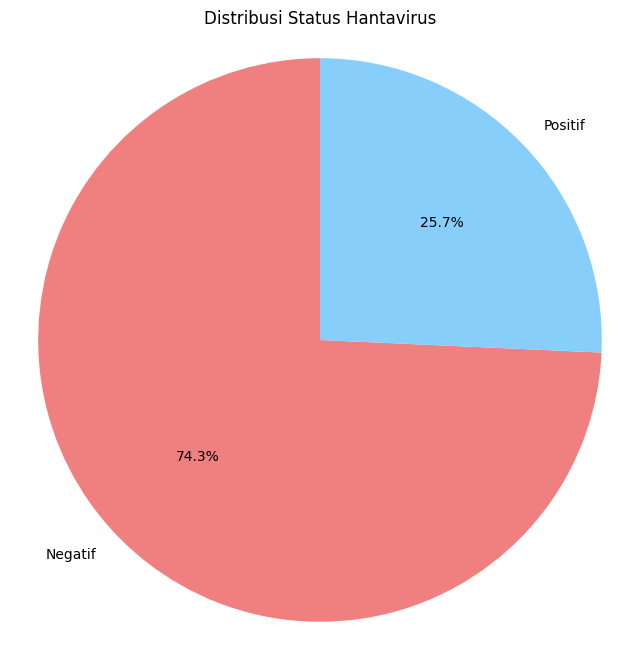

In [ ]:
import matplotlib.pyplot as plt  # Mengimpor library matplotlib.pyplot untuk membuat visualisasi grafik
import pandas as pd  # Mengimpor library pandas untuk pengolahan data

hantavirus_counts = df['Hantavirus_Positive'].value_counts()  # Menghitung jumlah kemunculan setiap kategori pada variabel Hantavirus_Positive
labels = ['Negatif' if x == 0 else 'Positif' for x in hantavirus_counts.index]  # Membuat label "Negatif" untuk nilai 0 dan "Positif" untuk nilai 1
colors = ['lightcoral', 'lightskyblue']  # Menentukan warna untuk masing-masing kategori pada diagram
plt.figure(figsize=(8, 8))  # Membuat kanvas gambar dengan ukuran 8x8 inci
plt.pie(  # Membuat diagram lingkaran (pie chart)
    hantavirus_counts,  # Data jumlah masing-masing kategori
    labels=labels,  # Menampilkan label pada setiap irisan diagram
    autopct='%1.1f%%',  # Menampilkan persentase dengan satu angka di belakang koma
    colors=colors,  # Memberikan warna pada setiap irisan diagram
    startangle=90  # Mengatur sudut awal diagram pada 90 derajat
)

plt.title('Distribusi Status Hantavirus')  # Memberikan judul pada diagram
plt.axis('equal')  # Mengatur rasio sumbu agar diagram berbentuk lingkaran sempurna
plt.show()  # Menampilkan diagram ke layar

Histogram

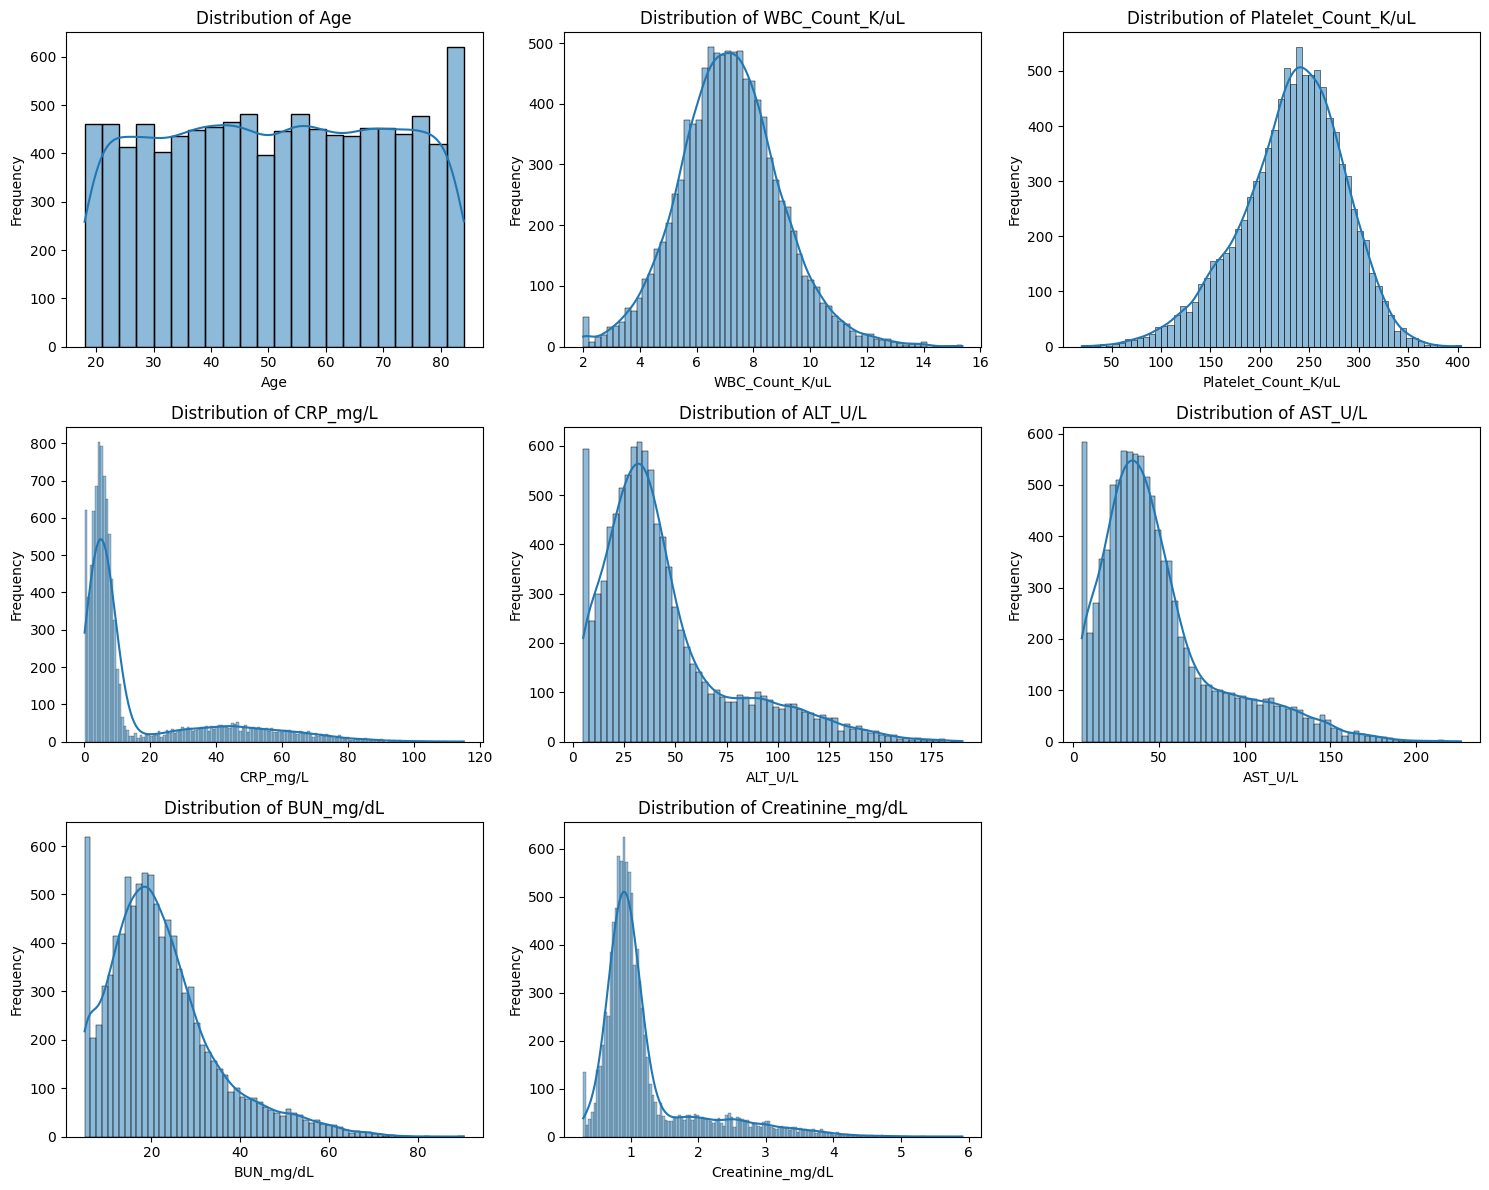

In [ ]:
import matplotlib.pyplot as plt #mengimpor library matplotlib.pyplot untuk membuat visualisasi grafik
import seaborn as sns #mengimpor library seaborn untuk visualisasi statistik yang lebih menarik

# Determine the number of columns in the DataFrame
num_cols = df.shape[1] #mengambil jumlah kolom pada dataframe df

# Calculate the number of rows and columns for the subplot grid
# Aim for a roughly square layout, or adjust as needed
num_rows = (num_cols + 2) // 3 #menghitung jumlah baris subplot dengan maksimal 3 grafik per baris
num_cols_plot = 3 #menentukan jumlah kolom subplot sebanyak 3

plt.figure(figsize=(num_cols_plot * 5, num_rows * 4)) #membuat figure utama dengan ukuran menyesuaikan jumlah subplot

for i, column in enumerate(df.columns.drop('Hantavirus_Positive')): #melakukan perulangan untuk setiap kolom pada dataframe
    plt.subplot(num_rows, num_cols_plot, i + 1) #membuat subplot pada posisi tertentu
    sns.histplot(df[column], kde=True) #membuat histogram distribusi data beserta garis KDE
    plt.title(f'Distribution of {column}') #memberikan judul grafik sesuai nama kolom
    plt.xlabel(column) #memberikan label sumbu x
    plt.ylabel('Frequency') #memberikan label sumbu y

plt.tight_layout() #mengatur jarak antar subplot agar tidak bertumpuk
plt.show() #menampilkan seluruh grafik

Boxplot

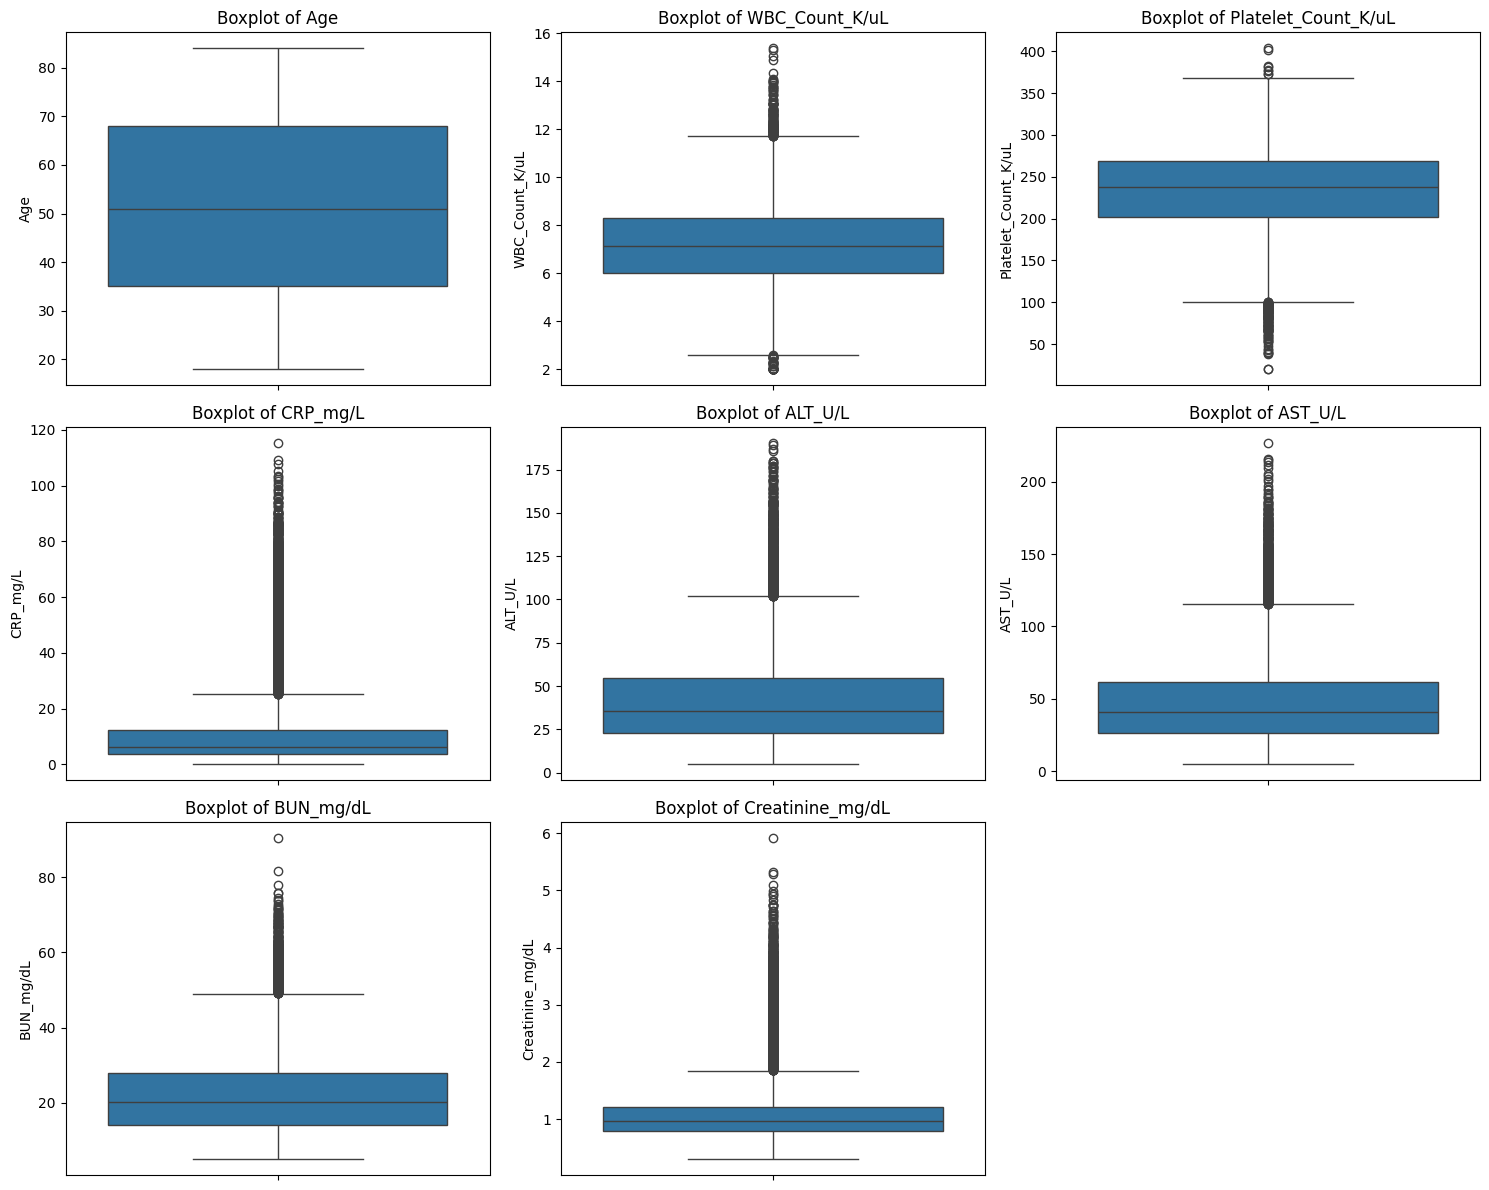

In [ ]:
import matplotlib.pyplot as plt #mengimpor library matplotlib.pyplot untuk membuat visualisasi grafik
import seaborn as sns #mengimpor library seaborn untuk membuat visualisasi statistik

# Determine the number of columns in the DataFrame
num_cols = df.shape[1] #mengambil jumlah kolom pada dataframe df

# Calculate the number of rows and columns for the subplot grid
# Aim for a roughly square layout, or adjust as needed
num_rows = (num_cols + 2) // 3 #menghitung jumlah baris subplot dengan maksimal 3 grafik per baris
num_cols_plot = 3 #menentukan jumlah kolom subplot sebanyak 3

plt.figure(figsize=(num_cols_plot * 5, num_rows * 4)) #membuat figure utama dengan ukuran menyesuaikan jumlah subplot

for i, column in enumerate(df.columns.drop('Hantavirus_Positive')): #melakukan perulangan untuk setiap kolom pada dataframe
    plt.subplot(num_rows, num_cols_plot, i + 1) #membuat subplot pada posisi tertentu
    sns.boxplot(y=df[column]) #membuat boxplot untuk melihat persebaran data dan outlier
    plt.title(f'Boxplot of {column}') #memberikan judul grafik sesuai nama kolom
    plt.ylabel(column) #memberikan label sumbu y sesuai nama kolom

plt.tight_layout() #mengatur jarak antar subplot agar tidak bertumpuk
plt.show() #menampilkan seluruh grafik

Scatter Plot

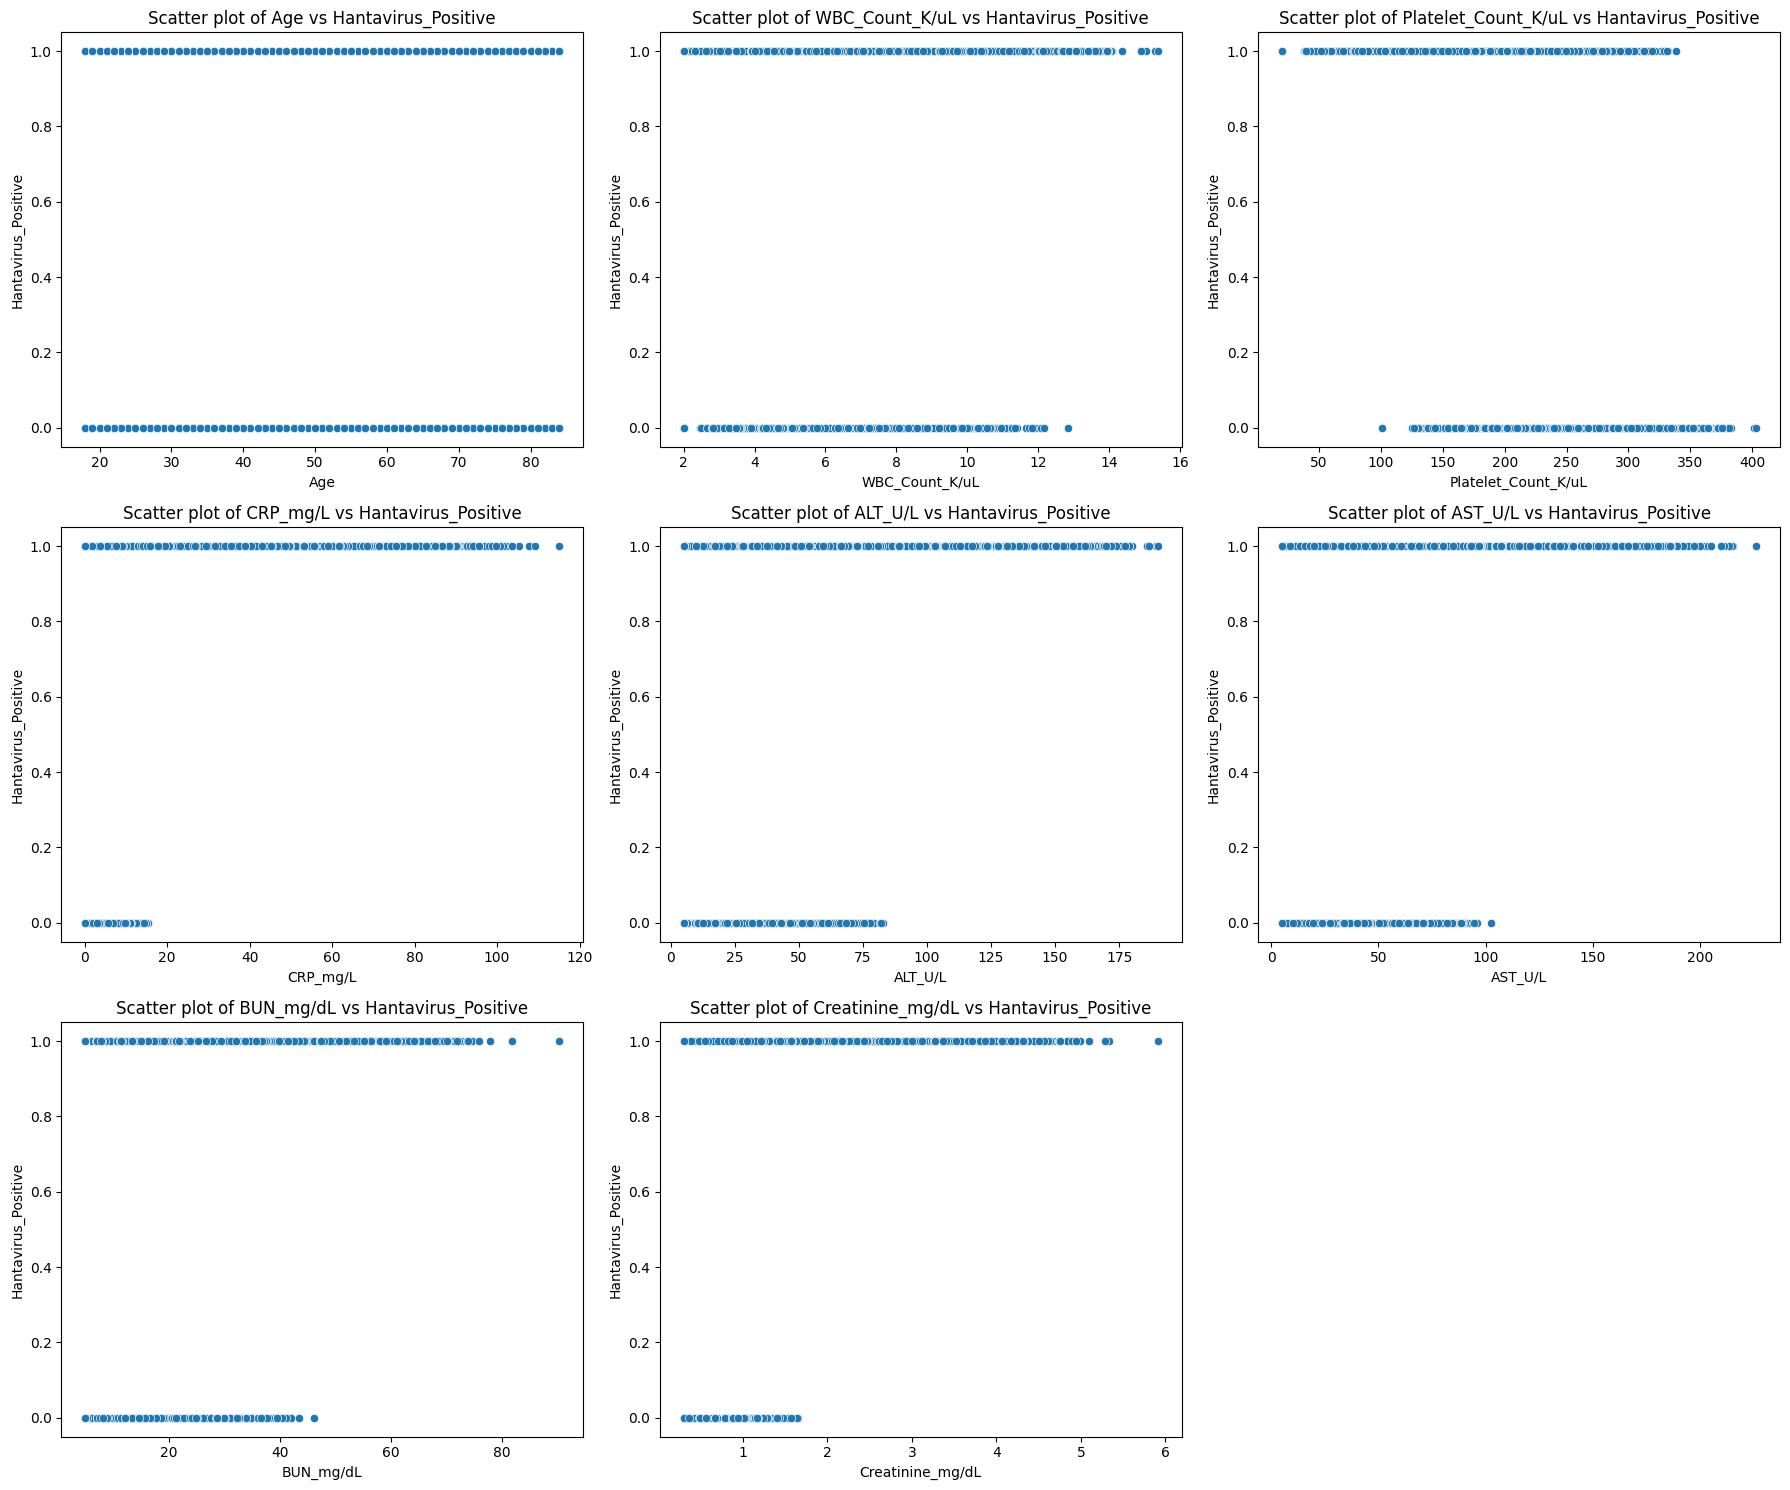

In [ ]:
import matplotlib.pyplot as plt #mengimpor library matplotlib.pyplot untuk membuat visualisasi grafik
import seaborn as sns #mengimpor library seaborn untuk visualisasi statistik

target_variable = 'Hantavirus_Positive' #menentukan variabel target yang akan dibandingkan dengan fitur lain

# Get all columns except the target variable
feature_columns = [col for col in df.columns if col != target_variable] #mengambil semua kolom selain variabel target

# Determine the number of feature columns
num_features = len(feature_columns) #menghitung jumlah fitur yang akan divisualisasikan

# Calculate the number of rows and columns for the subplot grid
# Aim for a roughly 3 columns per row
num_cols_plot = 3 #menentukan jumlah kolom subplot sebanyak 3
num_rows = (num_features + num_cols_plot - 1) // num_cols_plot #menghitung jumlah baris subplot yang diperlukan

plt.figure(figsize=(num_cols_plot * 6, num_rows * 5)) #membuat figure utama dengan ukuran menyesuaikan jumlah subplot

for i, column in enumerate(feature_columns): #melakukan perulangan untuk setiap fitur
    plt.subplot(num_rows, num_cols_plot, i + 1) #membuat subplot pada posisi tertentu
    sns.scatterplot(data=df, x=column, y=target_variable) #membuat scatter plot antara fitur dan variabel target
    plt.title(f'Scatter plot of {column} vs {target_variable}') #memberikan judul grafik
    plt.xlabel(column) #memberikan label sumbu x sesuai nama fitur
    plt.ylabel(target_variable) #memberikan label sumbu y sesuai nama target

plt.tight_layout() #mengatur jarak antar subplot agar tidak bertumpuk
plt.show() #menampilkan seluruh grafik

Heatmap Korelasi

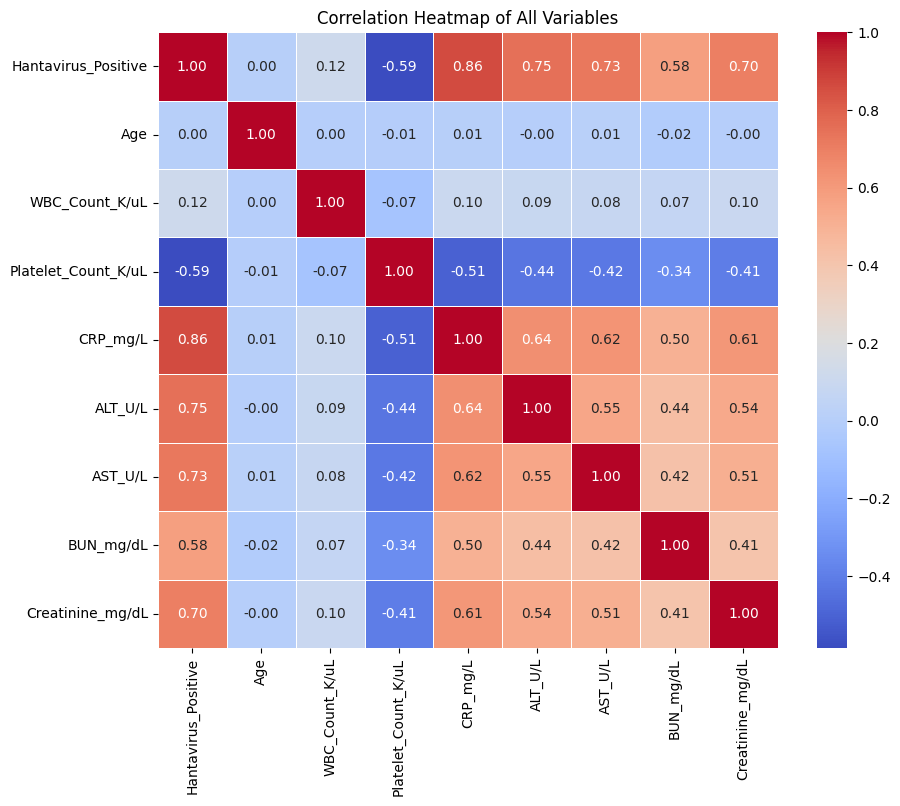

In [ ]:
import matplotlib.pyplot as plt #mengimpor library matplotlib.pyplot untuk membuat visualisasi grafik
import seaborn as sns #mengimpor library seaborn untuk visualisasi statistik

# Calculate the correlation matrix
correlation_matrix = df.corr() #menghitung matriks korelasi antar seluruh variabel numerik pada dataframe

# Set up the matplotlib figure
plt.figure(figsize=(10, 8)) #membuat figure dengan ukuran lebar 10 dan tinggi 8

# Draw the heatmap with seaborn
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5) #membuat heatmap korelasi dengan nilai korelasi ditampilkan pada setiap sel

# Add title
plt.title('Correlation Heatmap of All Variables') #memberikan judul pada heatmap

# Show the plot
plt.show() #menampilkan heatmap korelasi

Missing value dan Duplikasi

In [ ]:
print("Missing values in each column:") #menampilkan teks informasi missing values pada setiap kolom
print(df.isnull().sum()) #menghitung dan menampilkan jumlah nilai kosong (missing value) pada setiap kolom dataframe

print("\nNumber of duplicate rows:") #menampilkan teks informasi jumlah data duplikat
print(df.duplicated().sum()) #menghitung dan menampilkan jumlah baris yang terduplikasi pada dataframe

Missing values in each column:
Hantavirus_Positive    0
Age                    0
WBC_Count_K/uL         0
Platelet_Count_K/uL    0
CRP_mg/L               0
ALT_U/L                0
AST_U/L                0
BUN_mg/dL              0
Creatinine_mg/dL       0
dtype: int64

Number of duplicate rows:
0


Identifikasi missing value, duplikat, outlier, dan ketidakseimbangan kelas (untuk
klasifikasi).

Insight/temuan awal dari data yang ditulis dalam bentuk narasi.

PRAPEMROSESAN DAN REKAYASA FITUR

Standarisasi

In [ ]:
from sklearn.preprocessing import StandardScaler #mengimpor StandardScaler untuk melakukan standarisasi data

# Identify the target variable
target_variable = 'Hantavirus_Positive' #menentukan nama variabel target

# Separate features (X) and target (y)
X = df.drop(columns=[target_variable]) #memisahkan seluruh fitur selain target ke variabel X
y = df[target_variable] #mengambil kolom target ke variabel y

# Initialize the StandardScaler
scaler = StandardScaler() #membuat objek StandardScaler

# Fit and transform the feature columns
X_scaled = scaler.fit_transform(X) #menghitung mean dan standar deviasi lalu melakukan standarisasi data fitur

# Convert the scaled features back to a DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index) #mengubah hasil standarisasi menjadi dataframe kembali

# Recombine with the target variable to form the standardized DataFrame
df_scaled = pd.concat([X_scaled_df, y], axis=1) #menggabungkan fitur yang sudah distandarisasi dengan variabel target

print("Original DataFrame head:") #menampilkan teks informasi dataframe asli
print(df.head()) #menampilkan 5 baris pertama dataframe asli

print("\nStandardized DataFrame head (features only, target remains unscaled):") #menampilkan teks informasi dataframe hasil standarisasi
print(df_scaled.head()) #menampilkan 5 baris pertama dataframe hasil standarisasi

df = df_scaled.copy() #menyalin dataframe hasil standarisasi ke variabel df

Original DataFrame head:
   Hantavirus_Positive  Age  WBC_Count_K/uL  Platelet_Count_K/uL  CRP_mg/L  \
0                    0   69            7.42               290.42      3.26   
1                    0   76            8.43               228.22      5.33   
2                    0   61            7.48               194.26      0.10   
3                    0   57            4.25               216.26      3.46   
4                    1   25            5.26               174.40     74.38   

   ALT_U/L  AST_U/L  BUN_mg/dL  Creatinine_mg/dL  
0     22.1     24.7       10.6              0.38  
1     12.7     41.8       13.2              0.84  
2     14.3     38.1       20.6              1.05  
3     29.3     30.0        5.5              0.74  
4     45.7    133.0       60.9              2.56  

Standardized DataFrame head (features only, target remains unscaled):
        Age  WBC_Count_K/uL  Platelet_Count_K/uL  CRP_mg/L   ALT_U/L  \
0  0.923625        0.137309             1.103337 -0.59809

In [ ]:
import pandas as pd

print("--- Data Before Standardization (Features) ---")
print(X.head())
print("\n--- Data Before Standardization (Target) ---")
print(y.head())

print("\n--- Data After Standardization (Features and Target) ---")
print(df_scaled.head())

--- Data Before Standardization (Features) ---
   Age  WBC_Count_K/uL  Platelet_Count_K/uL  CRP_mg/L  ALT_U/L  AST_U/L  \
0   69            7.42               290.42      3.26     22.1     24.7   
1   76            8.43               228.22      5.33     12.7     41.8   
2   61            7.48               194.26      0.10     14.3     38.1   
3   57            4.25               216.26      3.46     29.3     30.0   
4   25            5.26               174.40     74.38     45.7    133.0   

   BUN_mg/dL  Creatinine_mg/dL  
0       10.6              0.38  
1       13.2              0.84  
2       20.6              1.05  
3        5.5              0.74  
4       60.9              2.56  

--- Data Before Standardization (Target) ---
0    0
1    0
2    0
3    0
4    1
Name: Hantavirus_Positive, dtype: int64

--- Data After Standardization (Features and Target) ---
        Age  WBC_Count_K/uL  Platelet_Count_K/uL  CRP_mg/L   ALT_U/L  \
0  0.923625        0.137309             1.103337 -0.5

In [ ]:
import pandas as pd

print("--- Data Before Standardization (Features) ---")
display(X.head())
print("\n--- Data Before Standardization (Target) ---")
display(y.head())

print("\n--- Data After Standardization (Features and Target) ---")
display(df_scaled.head())

--- Data Before Standardization (Features) ---


,Age,WBC_Count_K/uL,Platelet_Count_K/uL,CRP_mg/L,ALT_U/L,AST_U/L,BUN_mg/dL,Creatinine_mg/dL
0,69,7.42,290.42,3.26,22.1,24.7,10.6,0.38
1,76,8.43,228.22,5.33,12.7,41.8,13.2,0.84
2,61,7.48,194.26,0.10,14.3,38.1,20.6,1.05
3,57,4.25,216.26,3.46,29.3,30.0,5.5,0.74
4,25,5.26,174.40,74.38,45.7,133.0,60.9,2.56



--- Data Before Standardization (Target) ---


,Hantavirus_Positive
0,0
1,0
2,0
3,0
4,1



--- Data After Standardization (Features and Target) ---


,Age,WBC_Count_K/uL,Platelet_Count_K/uL,CRP_mg/L,ALT_U/L,AST_U/L,BUN_mg/dL,Creatinine_mg/dL,Hantavirus_Positive
0,0.923625,0.137309,1.103337,-0.598093,-0.694248,-0.713875,-0.955934,-1.116831,0
1,1.285195,0.696680,-0.084407,-0.496937,-0.984245,-0.236693,-0.744577,-0.494596,0
2,0.510403,0.170539,-0.732893,-0.752514,-0.934884,-0.339943,-0.143021,-0.210532,0
3,0.303791,-1.618339,-0.312790,-0.588319,-0.472122,-0.565976,-1.370520,-0.629864,0
4,-1.349100,-1.058969,-1.112131,2.877367,0.033832,2.308275,3.133021,1.832022,1


In [ ]:
from xgboost import XGBClassifier #mengimpor model XGBClassifier dari library xgboost
import pandas as pd #mengimpor library pandas untuk pengolahan data

# Define target variable
target_variable = 'Hantavirus_Positive' #menentukan nama variabel target

# Separate features (X) and target (y)
X = df.drop(columns=[target_variable]) #memisahkan seluruh fitur selain target ke variabel X
y = df[target_variable] #mengambil kolom target ke variabel y

# Initialize and train an XGBClassifier
# use_label_encoder=False dan eval_metric='logloss' ditambahkan untuk menghindari warning di versi baru
model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss') #membuat model XGBoost classifier
model.fit(X, y) #melatih model menggunakan data fitur dan target

# Get feature importances (XGBoost juga menggunakan atribut yang sama)
feature_importances = model.feature_importances_ #mengambil nilai tingkat kepentingan setiap fitur dari model

# Create a DataFrame to display feature importances
importance_df = pd.DataFrame({
    'Feature': X.columns, #menyimpan nama fitur
    'Importance': feature_importances #menyimpan nilai importance masing-masing fitur
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False) #mengurutkan fitur berdasarkan importance terbesar ke terkecil

print("Feature Importances for Hantavirus_Positive (XGBoost):") #menampilkan teks informasi feature importance
print(importance_df) #menampilkan dataframe feature importance

Feature Importances for Hantavirus_Positive (XGBoost):
               Feature  Importance
3             CRP_mg/L    0.905601
7     Creatinine_mg/dL    0.044654
4              ALT_U/L    0.031321
5              AST_U/L    0.007188
6            BUN_mg/dL    0.005837
2  Platelet_Count_K/uL    0.003454
1       WBC_Count_K/uL    0.001177
0                  Age    0.000767


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:34:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Menggunakan 5 Fitur Terbaik

In [ ]:
# Define the target variable y
y = df['Hantavirus_Positive'] #mengambil kolom Hantavirus_Positive sebagai variabel target (label)

# Define the feature variables X using the specified columns
X = df[['CRP_mg/L', 'Creatinine_mg/dL', 'ALT_U/L', 'AST_U/L', 'BUN_mg/dL']] #mengambil beberapa kolom fitur sebagai variabel input model

print("Shape of X:", X.shape) #menampilkan ukuran data fitur X (baris dan kolom)
print("Shape of y:", y.shape) #menampilkan ukuran data target y

print("\nFirst 5 rows of X:") #menampilkan teks keterangan 5 baris pertama data fitur
print(X.head()) #menampilkan 5 baris pertama dari data fitur X

print("\nFirst 5 values of y:") #menampilkan teks keterangan 5 data pertama target
print(y.head()) #menampilkan 5 nilai pertama dari variabel target y

Shape of X: (10000, 5)
Shape of y: (10000,)

First 5 rows of X:
   CRP_mg/L  Creatinine_mg/dL   ALT_U/L   AST_U/L  BUN_mg/dL
0 -0.598093         -1.116831 -0.694248 -0.713875  -0.955934
1 -0.496937         -0.494596 -0.984245 -0.236693  -0.744577
2 -0.752514         -0.210532 -0.934884 -0.339943  -0.143021
3 -0.588319         -0.629864 -0.472122 -0.565976  -1.370520
4  2.877367          1.832022  0.033832  2.308275   3.133021

First 5 values of y:
0    0
1    0
2    0
3    0
4    1
Name: Hantavirus_Positive, dtype: int64


Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split #mengimpor fungsi train_test_split untuk membagi data train dan test

# Split the data into training and testing sets (80:20 ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, #data fitur dan target yang akan dibagi
    test_size=0.2, #menentukan 20% data digunakan sebagai data testing
    random_state=42, #menentukan nilai acak agar hasil pembagian selalu sama
    stratify=y #menjaga proporsi kelas target tetap seimbang pada train dan test
)

print(f"Shape of X_train: {X_train.shape}") #menampilkan ukuran data fitur training
print(f"Shape of X_test: {X_test.shape}") #menampilkan ukuran data fitur testing
print(f"Shape of y_train: {y_train.shape}") #menampilkan ukuran data target training
print(f"Shape of y_test: {y_test.shape}") #menampilkan ukuran data target testing

print("\nValue counts for y_train (stratified):") #menampilkan distribusi kelas target pada data training
print(y_train.value_counts(normalize=True)) #menghitung proporsi masing-masing kelas pada y_train

print("\nValue counts for y_test (stratified):") #menampilkan distribusi kelas target pada data testing
print(y_test.value_counts(normalize=True)) #menghitung proporsi masing-masing kelas pada y_test

Shape of X_train: (8000, 5)
Shape of X_test: (2000, 5)
Shape of y_train: (8000,)
Shape of y_test: (2000,)

Value counts for y_train (stratified):
Hantavirus_Positive
0    0.742875
1    0.257125
Name: proportion, dtype: float64

Value counts for y_test (stratified):
Hantavirus_Positive
0    0.743
1    0.257
Name: proportion, dtype: float64


MODELING

Decision Tree

Decision Tree Classifier Performance:
Accuracy: 0.9915
Precision: 0.9825
Recall: 0.9844
F1-Score: 0.9835

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1486
           1       0.98      0.98      0.98       514

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



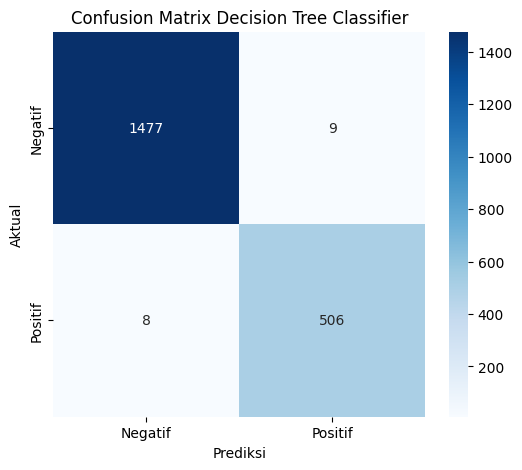

In [ ]:
from sklearn.tree import DecisionTreeClassifier #mengimpor algoritma Decision Tree untuk klasifikasi
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix #mengimpor metrik evaluasi model
import matplotlib.pyplot as plt #mengimpor matplotlib untuk visualisasi grafik
import seaborn as sns #mengimpor seaborn untuk visualisasi statistik

# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42) #membuat model Decision Tree Classifier dengan random state 42

# Train the model
dtc.fit(X_train, y_train) #melatih model menggunakan data training

# Make predictions on the test set
y_pred_dtc = dtc.predict(X_test) #melakukan prediksi pada data testing

# Evaluate the model
print("Decision Tree Classifier Performance:") #menampilkan teks informasi performa model

print(f"Accuracy: {accuracy_score(y_test, y_pred_dtc):.4f}") #menghitung dan menampilkan nilai accuracy model
print(f"Precision: {precision_score(y_test, y_pred_dtc):.4f}") #menghitung dan menampilkan nilai precision model
print(f"Recall: {recall_score(y_test, y_pred_dtc):.4f}") #menghitung dan menampilkan nilai recall model
print(f"F1-Score: {f1_score(y_test, y_pred_dtc):.4f}") #menghitung dan menampilkan nilai F1-Score model

print("\nClassification Report:") #menampilkan teks informasi classification report
print(classification_report(y_test, y_pred_dtc)) #menampilkan laporan klasifikasi secara lengkap

# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred_dtc)

# Menampilkan confusion matrix dalam bentuk heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,          # Menampilkan nilai pada setiap sel
    fmt='d',             # Format bilangan bulat
    cmap='Blues',        # Warna heatmap
    xticklabels=['Negatif', 'Positif'],  # Label prediksi
    yticklabels=['Negatif', 'Positif']   # Label aktual
)

# Memberikan judul dan label sumbu
plt.title('Confusion Matrix Decision Tree Classifier')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')

# Menampilkan grafik
plt.show()

KNN

K-Nearest Neighbors Classifier Performance:
Accuracy: 0.9960
Precision: 0.9980
Recall: 0.9864
F1-Score: 0.9922

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1486
           1       1.00      0.99      0.99       514

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



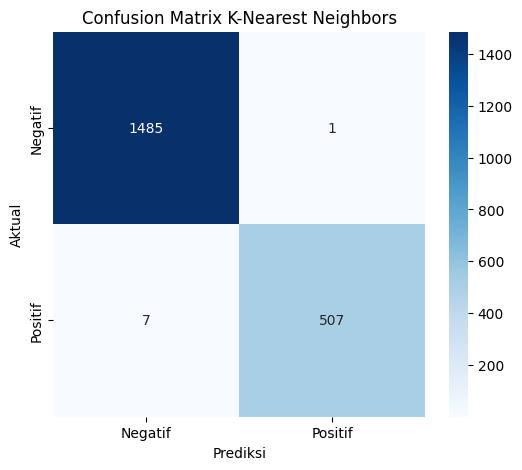

True Negative (TN): 1485
False Positive (FP): 1
False Negative (FN): 7
True Positive (TP): 507


In [ ]:
from sklearn.neighbors import KNeighborsClassifier #mengimpor algoritma K-Nearest Neighbors untuk klasifikasi
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix #mengimpor metrik evaluasi model
import matplotlib.pyplot as plt #mengimpor matplotlib untuk visualisasi grafik
import seaborn as sns #mengimpor seaborn untuk visualisasi statistik

# Initialize the K-Nearest Neighbors Classifier
# You might need to tune n_neighbors (e.g., to 3, 5, 7, etc.) based on performance
knn = KNeighborsClassifier(n_neighbors=5) #membuat model KNN dengan jumlah tetangga terdekat sebanyak 5

# Train the model
knn.fit(X_train, y_train) #melatih model menggunakan data training

# Make predictions on the test set
y_pred_knn = knn.predict(X_test) #melakukan prediksi pada data testing

# Evaluate the model
print("K-Nearest Neighbors Classifier Performance:") #menampilkan teks informasi performa model

print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}") #menghitung dan menampilkan nilai accuracy model
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}") #menghitung dan menampilkan nilai precision model
print(f"Recall: {recall_score(y_test, y_pred_knn):.4f}") #menghitung dan menampilkan nilai recall model
print(f"F1-Score: {f1_score(y_test, y_pred_knn):.4f}") #menghitung dan menampilkan nilai F1-Score model

print("\nClassification Report:") #menampilkan teks informasi classification report
print(classification_report(y_test, y_pred_knn)) #menampilkan laporan klasifikasi secara lengkap
# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred_knn)

# Menampilkan confusion matrix dalam bentuk heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,          # Menampilkan nilai pada setiap sel
    fmt='d',             # Format bilangan bulat
    cmap='Blues',        # Warna heatmap
    xticklabels=['Negatif', 'Positif'],  # Label prediksi
    yticklabels=['Negatif', 'Positif']   # Label aktual
)

# Memberikan judul dan label sumbu
plt.title('Confusion Matrix K-Nearest Neighbors')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')

# Menampilkan grafik
plt.show()

# Mengambil nilai TN, FP, FN, dan TP
tn, fp, fn, tp = cm.ravel()

# Menampilkan nilai TN, FP, FN, dan TP
print(f"True Negative (TN): {tn}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")
print(f"True Positive (TP): {tp}")

XGBoost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:41:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier Performance:
Accuracy: 0.9950
Precision: 0.9884
Recall: 0.9922
F1-Score: 0.9903

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1486
           1       0.99      0.99      0.99       514

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       1.00      0.99      1.00      2000

objective: binary:logistic
base_score: None
booster: None
callbacks: None
colsample_bylevel: None
colsample_bynode: None
colsample_bytree: None
device: None
early_stopping_rounds: None
enable_categorical: False
eval_metric: logloss
feature_types: None
feature_weights: None
gamma: None
grow_policy: None
importance_type: None
interaction_constraints: None
learning_rate: None
max_bin: None
max_cat_threshold: None
max_cat_to_onehot: None
max_delta_step: None
max_depth: None
max_leaves: None
min_child_weight: None
missing: nan
monotone_constraints: 

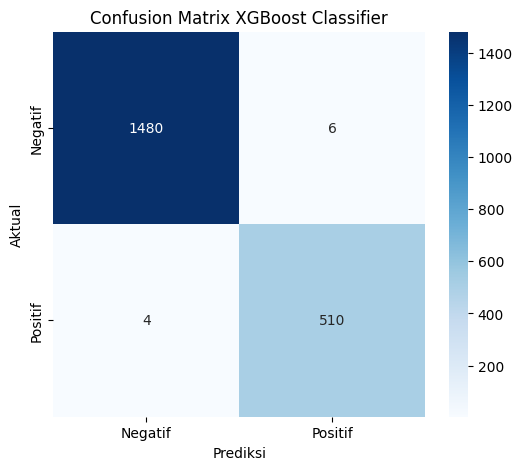

True Negative (TN): 1480
False Positive (FP): 6
False Negative (FN): 4
True Positive (TP): 510


In [ ]:
from xgboost import XGBClassifier #mengimpor algoritma XGBoost Classifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix #mengimpor metrik evaluasi model
import matplotlib.pyplot as plt #mengimpor matplotlib untuk visualisasi grafik
import seaborn as sns #mengimpor seaborn untuk visualisasi statistik

# Initialize the XGBoost Classifier
# Using use_label_encoder=False and eval_metric='logloss' to avoid warnings
xgb_model = XGBClassifier(
    random_state=42, #menentukan random state agar hasil konsisten
    use_label_encoder=False, #menonaktifkan label encoder bawaan untuk menghindari warning
    eval_metric='logloss' #menentukan metrik evaluasi logloss
)

# Train the model
xgb_model.fit(X_train, y_train) #melatih model menggunakan data training

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test) #melakukan prediksi pada data testing

# Evaluate the model
print("XGBoost Classifier Performance:") #menampilkan teks informasi performa model

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}") #menghitung dan menampilkan nilai accuracy model
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}") #menghitung dan menampilkan nilai precision model
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}") #menghitung dan menampilkan nilai recall model
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.4f}") #menghitung dan menampilkan nilai F1-Score model

print("\nClassification Report:") #menampilkan teks informasi classification report
print(classification_report(y_test, y_pred_xgb)) #menampilkan laporan klasifikasi secara lengkap
for key, value in xgb_model.get_params().items():
    print(f"{key}: {value}")
# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Menampilkan confusion matrix dalam bentuk heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,          # Menampilkan nilai pada setiap sel
    fmt='d',             # Format bilangan bulat
    cmap='Blues',        # Warna heatmap
    xticklabels=['Negatif', 'Positif'],  # Label prediksi
    yticklabels=['Negatif', 'Positif']   # Label aktual
)

# Memberikan judul dan label sumbu
plt.title('Confusion Matrix XGBoost Classifier')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')

# Menampilkan grafik
plt.show()

# Mengambil nilai True Negative, False Positive,
# False Negative, dan True Positive
tn, fp, fn, tp = cm.ravel()

# Menampilkan nilai TN, FP, FN, dan TP
print(f"True Negative (TN): {tn}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")
print(f"True Positive (TP): {tp}")

Mencari Model Terbaik

In [ ]:
from sklearn.metrics import recall_score #mengimpor fungsi recall_score untuk menghitung nilai recall model

# Calculate Recall for class 1 for each model
recall_dtc_class1 = recall_score(y_test, y_pred_dtc, pos_label=1) #menghitung recall kelas 1 untuk model Decision Tree
recall_knn_class1 = recall_score(y_test, y_pred_knn, pos_label=1) #menghitung recall kelas 1 untuk model KNN
recall_xgb_class1 = recall_score(y_test, y_pred_xgb, pos_label=1) #menghitung recall kelas 1 untuk model XGBoost

print("Recall for Class 1 (Hantavirus_Positive=1) for each model:") #menampilkan teks informasi recall kelas 1

print(f"Decision Tree Classifier: {recall_dtc_class1:.4f}") #menampilkan nilai recall kelas 1 model Decision Tree
print(f"K-Nearest Neighbors:      {recall_knn_class1:.4f}") #menampilkan nilai recall kelas 1 model KNN
print(f"XGBoost Classifier:       {recall_xgb_class1:.4f}") #menampilkan nilai recall kelas 1 model XGBoost

Recall for Class 1 (Hantavirus_Positive=1) for each model:
Decision Tree Classifier: 0.9942
K-Nearest Neighbors:      0.9903
XGBoost Classifier:       0.9981


Hyperparameter Tuning XGBoost

Starting Grid Search for XGBoost...
Fitting 3 folds for each of 243 candidates, totalling 729 fits
Grid Search complete.

Best Hyperparameters found: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}
Best Recall score from Grid Search: 0.9985

--- Tuned XGBoost Classifier Performance ---
Accuracy: 0.9990
Precision: 0.9981
Recall: 0.9981
F1-Score: 0.9981

Classification Report (Tuned XGBoost):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1486
           1       1.00      1.00      1.00       514

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:43:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


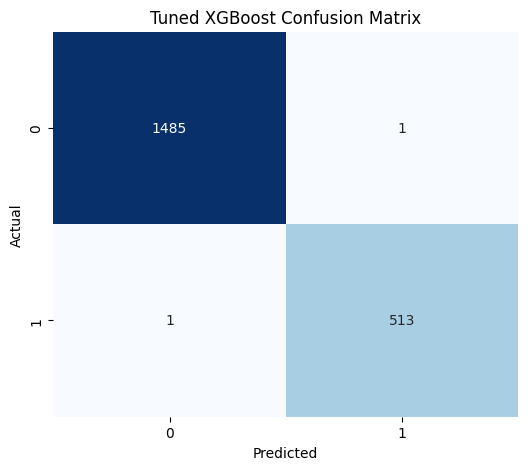

In [ ]:
from xgboost import XGBClassifier #mengimpor algoritma XGBoost Classifier
from sklearn.model_selection import GridSearchCV #mengimpor GridSearchCV untuk mencari hyperparameter terbaik
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix #mengimpor metrik evaluasi model
import matplotlib.pyplot as plt #mengimpor matplotlib untuk visualisasi grafik
import seaborn as sns #mengimpor seaborn untuk visualisasi statistik

# Define the XGBoost Classifier with a fixed random_state
xgb = XGBClassifier(
    random_state=42, #menentukan random state agar hasil konsisten
    use_label_encoder=False, #menonaktifkan label encoder bawaan untuk menghindari warning
    eval_metric='logloss' #menentukan metrik evaluasi logloss
)

# Define the hyperparameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300], #menentukan jumlah boosting rounds yang akan diuji
    'learning_rate': [0.01, 0.1, 0.2], #menentukan learning rate yang akan diuji
    'max_depth': [3, 5, 7], #menentukan kedalaman maksimum pohon keputusan
    'colsample_bytree': [0.7, 0.8, 1.0], #menentukan proporsi fitur yang digunakan tiap tree
    'gamma': [0, 0.1, 0.2] #menentukan minimum loss reduction untuk split node
}

# Initialize GridSearchCV
# Using recall as the scoring metric as it's often important in medical contexts (Hantavirus detection)
grid_search = GridSearchCV(
    estimator=xgb, #model yang akan dituning
    param_grid=param_grid, #kombinasi hyperparameter yang akan diuji
    scoring='recall', #menggunakan recall sebagai metrik evaluasi utama
    cv=3, #menggunakan 3-fold cross validation
    verbose=1, #menampilkan proses training
    n_jobs=-1 #menggunakan seluruh core CPU yang tersedia
)

# Fit GridSearchCV to the training data
print("Starting Grid Search for XGBoost...") #menampilkan informasi awal grid search
grid_search.fit(X_train, y_train) #melatih GridSearchCV menggunakan data training
print("Grid Search complete.") #menampilkan informasi bahwa grid search selesai

# Get the best parameters and best score
best_params = grid_search.best_params_ #mengambil hyperparameter terbaik hasil grid search
best_score = grid_search.best_score_ #mengambil nilai recall terbaik hasil grid search

print(f"\nBest Hyperparameters found: {best_params}") #menampilkan hyperparameter terbaik
print(f"Best Recall score from Grid Search: {best_score:.4f}") #menampilkan recall terbaik hasil tuning

# Get the best model
best_xgb_model = grid_search.best_estimator_ #mengambil model XGBoost terbaik hasil tuning

# Make predictions with the best model
y_pred_xgb_tuned = best_xgb_model.predict(X_test) #melakukan prediksi menggunakan model terbaik

# Evaluate the tuned model
print("\n--- Tuned XGBoost Classifier Performance ---") #menampilkan teks informasi performa model tuning

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_tuned):.4f}") #menghitung dan menampilkan accuracy model
print(f"Precision: {precision_score(y_test, y_pred_xgb_tuned):.4f}") #menghitung dan menampilkan precision model
print(f"Recall: {recall_score(y_test, y_pred_xgb_tuned):.4f}") #menghitung dan menampilkan recall model
print(f"F1-Score: {f1_score(y_test, y_pred_xgb_tuned):.4f}") #menghitung dan menampilkan F1-Score model

print("\nClassification Report (Tuned XGBoost):") #menampilkan teks informasi classification report
print(classification_report(y_test, y_pred_xgb_tuned)) #menampilkan laporan klasifikasi lengkap

# Confusion Matrix for the tuned model
cm_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned) #menghitung confusion matrix model tuning

plt.figure(figsize=(6, 5)) #membuat figure dengan ukuran 6x5
sns.heatmap(cm_xgb_tuned, annot=True, fmt='d', cmap='Blues', cbar=False) #membuat heatmap confusion matrix
plt.title('Tuned XGBoost Confusion Matrix') #memberikan judul grafik
plt.xlabel('Predicted') #memberikan label sumbu x
plt.ylabel('Actual') #memberikan label sumbu y
plt.show() #menampilkan confusion matrix


In [ ]:
print("\n=== All Hyperparameters of Best XGBoost Model ===") #menampilkan judul informasi hyperparameter model terbaik

for key, value in best_xgb_model.get_params().items(): #melakukan perulangan untuk mengambil semua hyperparameter dan nilainya
    print(f"{key}: {value}") #menampilkan nama hyperparameter beserta nilainya


=== All Hyperparameters of Best XGBoost Model ===
objective: binary:logistic
base_score: None
booster: None
callbacks: None
colsample_bylevel: None
colsample_bynode: None
colsample_bytree: 0.8
device: None
early_stopping_rounds: None
enable_categorical: False
eval_metric: logloss
feature_types: None
feature_weights: None
gamma: 0
grow_policy: None
importance_type: None
interaction_constraints: None
learning_rate: 0.2
max_bin: None
max_cat_threshold: None
max_cat_to_onehot: None
max_delta_step: None
max_depth: 5
max_leaves: None
min_child_weight: None
missing: nan
monotone_constraints: None
multi_strategy: None
n_estimators: 100
n_jobs: None
num_parallel_tree: None
random_state: 42
reg_alpha: None
reg_lambda: None
sampling_method: None
scale_pos_weight: None
subsample: None
tree_method: None
validate_parameters: None
verbosity: None
use_label_encoder: False


Sebelum dan Sesudah Hyperparamter Tuning

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score #mengimpor metrik evaluasi model klasifikasi
print("--- XGBoost Classifier Performance (Before Tuning) ---") #menampilkan judul evaluasi model sebelum tuning
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}") #menghitung dan menampilkan nilai akurasi model sebelum tuning
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}") #menghitung dan menampilkan nilai precision model sebelum tuning
print(f"Recall (Class 1): {recall_score(y_test, y_pred_xgb, pos_label=1):.4f}") #menghitung dan menampilkan nilai recall untuk kelas positif (1) sebelum tuning
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.4f}") #menghitung dan menampilkan nilai F1-Score model sebelum tuning
print("\n--- XGBoost Classifier Performance (After Tuning) ---") #menampilkan judul evaluasi model setelah tuning
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_tuned):.4f}") #menghitung dan menampilkan nilai akurasi model setelah tuning
print(f"Precision: {precision_score(y_test, y_pred_xgb_tuned):.4f}") #menghitung dan menampilkan nilai precision model setelah tuning
print(f"Recall (Class 1): {recall_score(y_test, y_pred_xgb_tuned, pos_label=1):.4f}") #menghitung dan menampilkan nilai recall untuk kelas positif (1) setelah tuning
print(f"F1-Score: {f1_score(y_test, y_pred_xgb_tuned):.4f}") #menghitung dan menampilkan nilai F1-Score model setelah tuning

--- XGBoost Classifier Performance (Before Tuning) ---
Accuracy: 0.9990
Precision: 0.9981
Recall (Class 1): 0.9981
F1-Score: 0.9981

--- XGBoost Classifier Performance (After Tuning) ---
Accuracy: 0.9990
Precision: 0.9981
Recall (Class 1): 0.9981
F1-Score: 0.9981


Tabel Ringkasan Performa Seluruh Model

In [ ]:
import pandas as pd #mengimpor library pandas untuk pengolahan data
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score #mengimpor metrik evaluasi model

# --- Gather metrics for Decision Tree (Untuned) ---
acc_dtc = accuracy_score(y_test, y_pred_dtc) #menghitung accuracy model Decision Tree
prec_dtc = precision_score(y_test, y_pred_dtc, pos_label=1) #menghitung precision kelas 1 model Decision Tree
rec_dtc = recall_score(y_test, y_pred_dtc, pos_label=1) #menghitung recall kelas 1 model Decision Tree
f1_dtc = f1_score(y_test, y_pred_dtc, pos_label=1) #menghitung F1-Score kelas 1 model Decision Tree

# --- Gather metrics for KNN (Untuned) ---
acc_knn = accuracy_score(y_test, y_pred_knn) #menghitung accuracy model KNN
prec_knn = precision_score(y_test, y_pred_knn, pos_label=1) #menghitung precision kelas 1 model KNN
rec_knn = recall_score(y_test, y_pred_knn, pos_label=1) #menghitung recall kelas 1 model KNN
f1_knn = f1_score(y_test, y_pred_knn, pos_label=1) #menghitung F1-Score kelas 1 model KNN

# --- Gather metrics for XGBoost (Untuned) ---
acc_xgb = accuracy_score(y_test, y_pred_xgb) #menghitung accuracy model XGBoost tanpa tuning
prec_xgb = precision_score(y_test, y_pred_xgb, pos_label=1) #menghitung precision kelas 1 model XGBoost tanpa tuning
rec_xgb = recall_score(y_test, y_pred_xgb, pos_label=1) #menghitung recall kelas 1 model XGBoost tanpa tuning
f1_xgb = f1_score(y_test, y_pred_xgb, pos_label=1) #menghitung F1-Score kelas 1 model XGBoost tanpa tuning

# --- Gather metrics for XGBoost (Tuned) ---
acc_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned) #menghitung accuracy model XGBoost hasil tuning
prec_xgb_tuned = precision_score(y_test, y_pred_xgb_tuned, pos_label=1) #menghitung precision kelas 1 model XGBoost hasil tuning
rec_xgb_tuned = recall_score(y_test, y_pred_xgb_tuned, pos_label=1) #menghitung recall kelas 1 model XGBoost hasil tuning
f1_xgb_tuned = f1_score(y_test, y_pred_xgb_tuned, pos_label=1) #menghitung F1-Score kelas 1 model XGBoost hasil tuning

# Create a DataFrame to store the performance metrics
performance_data = {
    'Model': [ #menyimpan nama model
        'Decision Tree (Untuned)',
        'KNN (Untuned)',
        'XGBoost (Untuned)',
        'XGBoost (Tuned)'
    ],
    'Accuracy': [ #menyimpan nilai accuracy setiap model
        acc_dtc, acc_knn, acc_xgb, acc_xgb_tuned
    ],
    'Precision (Class 1)': [ #menyimpan nilai precision kelas 1 setiap model
        prec_dtc, prec_knn, prec_xgb, prec_xgb_tuned
    ],
    'Recall (Class 1)': [ #menyimpan nilai recall kelas 1 setiap model
        rec_dtc, rec_knn, rec_xgb, rec_xgb_tuned
    ],
    'F1-Score (Class 1)': [ #menyimpan nilai F1-Score kelas 1 setiap model
        f1_dtc, f1_knn, f1_xgb, f1_xgb_tuned
    ]
}

performance_df = pd.DataFrame(performance_data) #membuat dataframe berisi perbandingan performa model

print("--- Model Performance Comparison ---") #menampilkan teks informasi perbandingan performa model
print(performance_df.round(4).to_string(index=False)) #menampilkan dataframe performa model dengan 4 angka desimal

--- Model Performance Comparison ---
                  Model  Accuracy  Precision (Class 1)  Recall (Class 1)  F1-Score (Class 1)
Decision Tree (Untuned)    0.9975               0.9961            0.9942              0.9951
          KNN (Untuned)    0.9975               1.0000            0.9903              0.9951
      XGBoost (Untuned)    0.9990               0.9981            0.9981              0.9981
        XGBoost (Tuned)    0.9990               0.9981            0.9981              0.9981


FEATURE SELECTION LANJUTAN

3 Fitur Terbaik

In [ ]:
# Get the top 3 feature names from the importance_df DataFrame
top_3_features = importance_df['Feature'].head(3).tolist() #mengambil 3 nama fitur teratas berdasarkan feature importance dan mengubahnya menjadi list
# Define the target variable y (assuming it's still 'Hantavirus_Positive')
y = df['Hantavirus_Positive'] #mengambil kolom Hantavirus_Positive sebagai variabel target
# Define the feature variables X using only the top 3 features
X = df[top_3_features] #mengambil data fitur hanya dari 3 fitur terbaik

print(f"Using the following top 3 features: {top_3_features}") #menampilkan nama 3 fitur terbaik yang digunakan
print("\nShape of X:", X.shape) #menampilkan ukuran data fitur X
print("Shape of y:", y.shape) #menampilkan ukuran data target y
print("\nFirst 5 rows of X (with top 3 features):") #menampilkan teks keterangan 5 data pertama fitur
print(X.head()) #menampilkan 5 baris pertama dari data fitur X
print("\nFirst 5 values of y:") #menampilkan teks keterangan 5 data pertama target
print(y.head()) #menampilkan 5 nilai pertama dari variabel target y

Using the following top 3 features: ['CRP_mg/L', 'Creatinine_mg/dL', 'ALT_U/L']

Shape of X: (10000, 3)
Shape of y: (10000,)

First 5 rows of X (with top 3 features):
   CRP_mg/L  Creatinine_mg/dL   ALT_U/L
0 -0.598093         -1.116831 -0.694248
1 -0.496937         -0.494596 -0.984245
2 -0.752514         -0.210532 -0.934884
3 -0.588319         -0.629864 -0.472122
4  2.877367          1.832022  0.033832

First 5 values of y:
0    0
1    0
2    0
3    0
4    1
Name: Hantavirus_Positive, dtype: int64


Initializing XGBoost model with 3 features and parameters: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': 0, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.2, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 5, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None, 'use_label_encoder': F

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:44:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


F1-Score: 0.9981

Classification Report (XGBoost 3 Features):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1486
           1       1.00      1.00      1.00       514

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



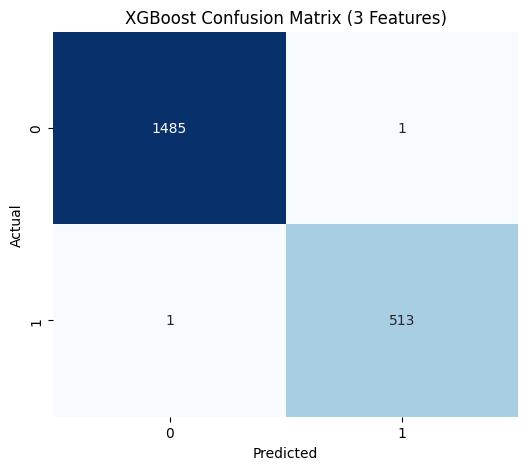

In [ ]:
from xgboost import XGBClassifier #mengimpor algoritma XGBoost Classifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report #mengimpor metrik evaluasi model klasifikasi

# Define the hyperparameters as requested by the user
hyperparameters_xgb_3_features = { #membuat dictionary hyperparameter model XGBoost
    'objective': 'binary:logistic', #menentukan klasifikasi biner
    'base_score': None, #mengatur skor awal model
    'booster': None, #menentukan jenis booster
    'callbacks': None, #mengatur callback tambahan
    'colsample_bylevel': None, #mengatur proporsi fitur tiap level
    'colsample_bynode': None, #mengatur proporsi fitur tiap node
    'colsample_bytree': 0.8, #menggunakan 80% fitur tiap tree
    'device': None, #mengatur device komputasi
    'early_stopping_rounds': None, #mengatur early stopping
    'enable_categorical': False, #menonaktifkan fitur kategorikal
    'eval_metric': 'logloss', #menggunakan logloss sebagai evaluasi
    'feature_types': None, #mengatur tipe fitur
    'feature_weights': None, #mengatur bobot fitur
    'gamma': 0, #mengatur minimum loss reduction
    'grow_policy': None, #mengatur kebijakan pertumbuhan tree
    'importance_type': None, #mengatur tipe importance
    'interaction_constraints': None, #mengatur batasan interaksi fitur
    'learning_rate': 0.2, #mengatur learning rate
    'max_bin': None, #mengatur maksimum bin
    'max_cat_threshold': None, #mengatur threshold kategori maksimum
    'max_cat_to_onehot': None, #mengatur konversi kategori one-hot
    'max_delta_step': None, #mengatur maksimum delta step
    'max_depth': 5, #mengatur kedalaman maksimum tree
    'max_leaves': None, #mengatur jumlah leaf maksimum
    'min_child_weight': None, #mengatur minimum child weight
    'missing': float('nan'), #mengatur missing value sebagai NaN
    'monotone_constraints': None, #mengatur monotone constraints
    'multi_strategy': None, #mengatur strategi multi-output
    'n_estimators': 100, #mengatur jumlah estimator
    'n_jobs': None, #mengatur jumlah CPU
    'num_parallel_tree': None, #mengatur jumlah tree paralel
    'random_state': 42, #mengatur random state
    'reg_alpha': None, #mengatur regularisasi L1
    'reg_lambda': None, #mengatur regularisasi L2
    'sampling_method': None, #mengatur metode sampling
    'scale_pos_weight': None, #mengatur bobot kelas positif
    'subsample': None, #mengatur proporsi subsample
    'tree_method': None, #mengatur metode tree
    'validate_parameters': None, #mengatur validasi parameter
    'verbosity': None, #mengatur tingkat output
    'use_label_encoder': False #menonaktifkan label encoder lama
}

# Initialize the XGBoost Classifier with the specified hyperparameters
xgb_3_features_model = XGBClassifier(**hyperparameters_xgb_3_features) #membuat model XGBoost dengan hyperparameter yang ditentukan

print(f"Initializing XGBoost model with 3 features and parameters: {hyperparameters_xgb_3_features}") #menampilkan informasi parameter model

# Train the model using the X_train and y_train that were updated to use 3 features
xgb_3_features_model.fit(X_train, y_train) #melatih model menggunakan data training

# Make predictions on the test set
y_pred_xgb_3_features = xgb_3_features_model.predict(X_test) #melakukan prediksi pada data testing

# Evaluate the model
print("\n--- XGBoost Classifier Performance (3 Features) ---") #menampilkan judul evaluasi model
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_3_features):.4f}") #menghitung dan menampilkan accuracy
print(f"Precision: {precision_score(y_test, y_pred_xgb_3_features):.4f}") #menghitung dan menampilkan precision
print(f"Recall: {recall_score(y_test, y_pred_xgb_3_features):.4f}") #menghitung dan menampilkan recall
print(f"F1-Score: {f1_score(y_test, y_pred_xgb_3_features):.4f}") #menghitung dan menampilkan F1-Score

print("\nClassification Report (XGBoost 3 Features):") #menampilkan judul classification report
print(classification_report(y_test, y_pred_xgb_3_features)) #menampilkan classification report lengkap

# Calculate the confusion matrix for the XGBoost model with 3 features
cm_xgb_3_features = confusion_matrix(y_test, y_pred_xgb_3_features) #menghitung confusion matrix

# Visualize the confusion matrix
plt.figure(figsize=(6, 5)) #membuat ukuran figure
sns.heatmap(cm_xgb_3_features, annot=True, fmt='d', cmap='Blues', cbar=False) #membuat heatmap confusion matrix
plt.title('XGBoost Confusion Matrix (3 Features)') #memberikan judul grafik
plt.xlabel('Predicted') #memberikan label sumbu x
plt.ylabel('Actual') #memberikan label sumbu y
plt.show() #menampilkan grafik

2 Fitur Terbaik

In [ ]:
# Get the top 2 feature names from the importance_df DataFrame
top_2_features = importance_df['Feature'].head(2).tolist() #mengambil 2 nama fitur teratas berdasarkan feature importance dan mengubahnya menjadi list

# Define the target variable y (assuming it's still 'Hantavirus_Positive')
y = df['Hantavirus_Positive'] #mengambil kolom Hantavirus_Positive sebagai variabel target

# Define the feature variables X using only the top 2 features
X = df[top_2_features] #mengambil data fitur hanya dari 2 fitur terbaik

print(f"Using the following top 2 features: {top_2_features}") #menampilkan nama 2 fitur terbaik yang digunakan
print("\nShape of X:", X.shape) #menampilkan ukuran data fitur X
print("Shape of y:", y.shape) #menampilkan ukuran data target y
print("\nFirst 5 rows of X (with top 2 features):") #menampilkan teks keterangan 5 data pertama fitur
print(X.head()) #menampilkan 5 baris pertama dari data fitur X
print("\nFirst 5 values of y:") #menampilkan teks keterangan 5 data pertama target
print(y.head()) #menampilkan 5 nilai pertama dari variabel target y

Using the following top 2 features: ['CRP_mg/L', 'Creatinine_mg/dL']

Shape of X: (10000, 2)
Shape of y: (10000,)

First 5 rows of X (with top 2 features):
   CRP_mg/L  Creatinine_mg/dL
0 -0.598093         -1.116831
1 -0.496937         -0.494596
2 -0.752514         -0.210532
3 -0.588319         -0.629864
4  2.877367          1.832022

First 5 values of y:
0    0
1    0
2    0
3    0
4    1
Name: Hantavirus_Positive, dtype: int64


Using the following top 2 features: ['CRP_mg/L', 'Creatinine_mg/dL']

Shape of X: (10000, 2)
Shape of y: (10000,)

Shape of X_train (2 features): (8000, 2)
Shape of X_test (2 features): (2000, 2)

Initializing XGBoost model with 2 features and parameters: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': 0, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.2, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 5, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 're

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:44:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


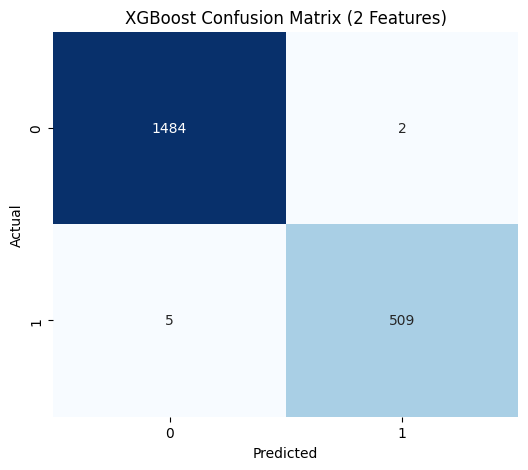

In [ ]:
from sklearn.model_selection import train_test_split #mengimpor fungsi untuk membagi data training dan testing
from xgboost import XGBClassifier #mengimpor algoritma XGBoost Classifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix #mengimpor metrik evaluasi model
import matplotlib.pyplot as plt #mengimpor matplotlib untuk visualisasi grafik
import seaborn as sns #mengimpor seaborn untuk membuat heatmap confusion matrix

# Assuming 'df' and 'importance_df' are already defined from previous steps
# Get the top 2 feature names from the importance_df DataFrame
top_2_features = importance_df['Feature'].head(2).tolist() #mengambil 2 fitur terbaik berdasarkan feature importance

# Define the target variable y (assuming it's still 'Hantavirus_Positive')
y = df['Hantavirus_Positive'] #mengambil kolom target Hantavirus_Positive

# Define the feature variables X using only the top 2 features
X = df[top_2_features] #mengambil data fitur menggunakan 2 fitur terbaik

print(f"Using the following top 2 features: {top_2_features}") #menampilkan nama 2 fitur terbaik yang digunakan
print("\nShape of X:", X.shape) #menampilkan ukuran data fitur
print("Shape of y:", y.shape) #menampilkan ukuran data target

# Re-split the data into training and testing sets (80:20 ratio) for the 2 features
X_train, X_test, y_train, y_test = train_test_split(
    X, y, #data fitur dan target yang akan dibagi
    test_size=0.2, #menentukan 20% data digunakan sebagai data testing
    random_state=42, #menentukan nilai acak agar hasil pembagian selalu sama
    stratify=y #menjaga proporsi kelas target tetap seimbang pada train dan test
)

print(f"\nShape of X_train (2 features): {X_train.shape}") #menampilkan ukuran data training
print(f"Shape of X_test (2 features): {X_test.shape}") #menampilkan ukuran data testing

# Define the hyperparameters as requested by the user
hyperparameters_xgb_2_features = { #membuat dictionary hyperparameter model XGBoost
    'objective': 'binary:logistic', #menentukan klasifikasi biner
    'base_score': None, #mengatur skor awal model
    'booster': None, #menentukan jenis booster
    'callbacks': None, #mengatur callback tambahan
    'colsample_bylevel': None, #mengatur proporsi fitur tiap level
    'colsample_bynode': None, #mengatur proporsi fitur tiap node
    'colsample_bytree': 0.8, #menggunakan 80% fitur tiap tree
    'device': None, #mengatur device komputasi
    'early_stopping_rounds': None, #mengatur early stopping
    'enable_categorical': False, #menonaktifkan fitur kategorikal
    'eval_metric': 'logloss', #menggunakan logloss sebagai evaluasi
    'feature_types': None, #mengatur tipe fitur
    'feature_weights': None, #mengatur bobot fitur
    'gamma': 0, #mengatur minimum loss reduction
    'grow_policy': None, #mengatur kebijakan pertumbuhan tree
    'importance_type': None, #mengatur tipe importance
    'interaction_constraints': None, #mengatur batasan interaksi fitur
    'learning_rate': 0.2, #mengatur learning rate
    'max_bin': None, #mengatur maksimum bin
    'max_cat_threshold': None, #mengatur threshold kategori maksimum
    'max_cat_to_onehot': None, #mengatur konversi kategori one-hot
    'max_delta_step': None, #mengatur maksimum delta step
    'max_depth': 5, #mengatur kedalaman maksimum tree
    'max_leaves': None, #mengatur jumlah leaf maksimum
    'min_child_weight': None, #mengatur minimum child weight
    'missing': float('nan'), #mengatur missing value sebagai NaN
    'monotone_constraints': None, #mengatur monotone constraints
    'multi_strategy': None, #mengatur strategi multi-output
    'n_estimators': 100, #mengatur jumlah estimator
    'n_jobs': None, #mengatur jumlah CPU
    'num_parallel_tree': None, #mengatur jumlah tree paralel
    'random_state': 42, #mengatur random state
    'reg_alpha': None, #mengatur regularisasi L1
    'reg_lambda': None, #mengatur regularisasi L2
    'sampling_method': None, #mengatur metode sampling
    'scale_pos_weight': None, #mengatur bobot kelas positif
    'subsample': None, #mengatur proporsi subsample
    'tree_method': None, #mengatur metode tree
    'validate_parameters': None, #mengatur validasi parameter
    'verbosity': None, #mengatur tingkat output
    'use_label_encoder': False #menonaktifkan label encoder lama
}

# Initialize the XGBoost Classifier with the specified hyperparameters
xgb_2_features_model = XGBClassifier(**hyperparameters_xgb_2_features) #membuat model XGBoost menggunakan hyperparameter yang ditentukan

print(f"\nInitializing XGBoost model with 2 features and parameters: {hyperparameters_xgb_2_features}") #menampilkan informasi parameter model

# Train the model using the updated X_train and y_train
xgb_2_features_model.fit(X_train, y_train) #melatih model menggunakan data training

# Make predictions on the test set
y_pred_xgb_2_features = xgb_2_features_model.predict(X_test) #melakukan prediksi pada data testing

# Evaluate the model
print("\n--- XGBoost Classifier Performance (2 Features) ---") #menampilkan judul evaluasi model
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_2_features):.4f}") #menghitung dan menampilkan accuracy
print(f"Precision: {precision_score(y_test, y_pred_xgb_2_features):.4f}") #menghitung dan menampilkan precision
print(f"Recall: {recall_score(y_test, y_pred_xgb_2_features):.4f}") #menghitung dan menampilkan recall
print(f"F1-Score: {f1_score(y_test, y_pred_xgb_2_features):.4f}") #menghitung dan menampilkan F1-Score

print("\nClassification Report (XGBoost 2 Features):") #menampilkan judul classification report
print(classification_report(y_test, y_pred_xgb_2_features)) #menampilkan classification report lengkap

# Calculate and visualize the confusion matrix
cm_xgb_2_features = confusion_matrix(y_test, y_pred_xgb_2_features) #menghitung confusion matrix

plt.figure(figsize=(6, 5)) #membuat ukuran figure
sns.heatmap(cm_xgb_2_features, annot=True, fmt='d', cmap='Blues', cbar=False) #membuat heatmap confusion matrix
plt.title('XGBoost Confusion Matrix (2 Features)') #memberikan judul grafik
plt.xlabel('Predicted') #memberikan label sumbu x
plt.ylabel('Actual') #memberikan label sumbu y
plt.show() #menampilkan grafik

Perbandingan confusion matrix

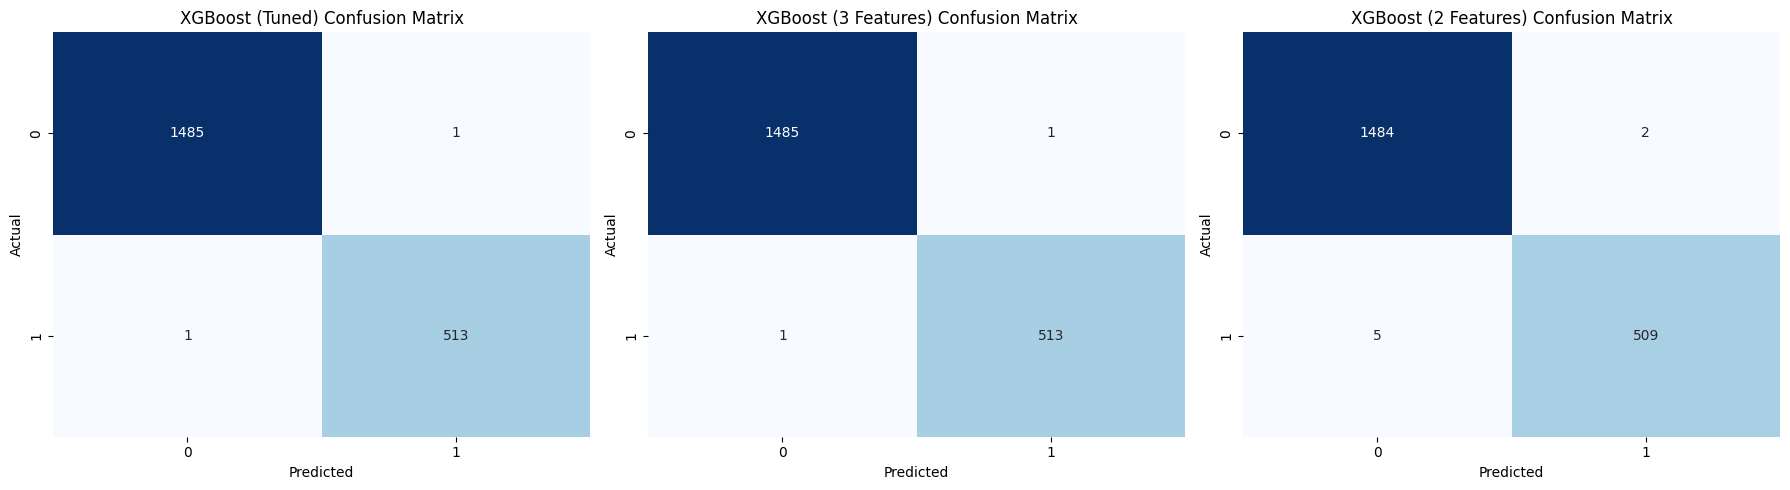

In [ ]:
from sklearn.metrics import confusion_matrix #mengimpor fungsi confusion matrix
import matplotlib.pyplot as plt #mengimpor matplotlib untuk visualisasi grafik
import seaborn as sns #mengimpor seaborn untuk membuat heatmap

confusion_matrices = { #membuat dictionary berisi confusion matrix model XGBoost
    'XGBoost (Tuned)': cm_xgb_tuned, #menyimpan confusion matrix XGBoost hasil tuning
    'XGBoost (3 Features)': cm_xgb_3_features, #menyimpan confusion matrix XGBoost dengan 3 fitur
    'XGBoost (2 Features)': cm_xgb_2_features #menyimpan confusion matrix XGBoost dengan 2 fitur
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5)) #membuat canvas subplot 1 baris dan 3 kolom
axes = axes.flatten() #mengubah array subplot menjadi 1 dimensi agar mudah diakses

for i, (model_name, cm) in enumerate(confusion_matrices.items()): #melakukan perulangan untuk setiap confusion matrix model
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i]) #membuat heatmap confusion matrix
    axes[i].set_title(f'{model_name} Confusion Matrix') #memberikan judul pada setiap subplot
    axes[i].set_xlabel('Predicted') #memberikan label sumbu x
    axes[i].set_ylabel('Actual') #memberikan label sumbu y

plt.tight_layout() #mengatur layout agar subplot tidak saling bertumpuk
plt.show() #menampilkan seluruh grafik confusion matrix